# 23CSE301 Machine Learning Capstone: Regression Track
**Team:** 5 

**Dataset:** all_bikez_curated.csv

**Objective:** Predict motorcycle Power (hp) using engine and physical specifications.

## Section A: Dataset & Exploratory Data Analysis (EDA)

### A1. Dataset Loading & Initial Audit
Loading the raw dataset and inspecting data types, shape, and missing values.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/all_bikez_curated.csv')
df.head()

C:\Users\Gopi\AppData\Local\Temp\ipykernel_29924\761036185.py:6: DtypeWarning: Columns (0: Stroke (mm)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/all_bikez_curated.csv')


,Brand,Model,Year,Category,Rating,Displacement (ccm),Power (hp),Torque (Nm),Engine cylinder,Engine stroke,...,Dry weight (kg),Wheelbase (mm),Seat height (mm),Front brakes,Rear brakes,Front tire,Rear tire,Front suspension,Rear suspension,Color options
0,acabion,da vinci 650-vi,2011,Prototype / concept model,3.2,NaN,804.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN
1,acabion,gtbo 55,2007,Sport,2.6,1300.0,541.0,420.0,In-line four,four-stroke,...,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,acabion,gtbo 600 daytona-vi,2011,Prototype / concept model,3.5,NaN,536.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN
3,acabion,gtbo 600 daytona-vi,2021,Prototype / concept model,NaN,NaN,536.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN
4,acabion,gtbo 70,2007,Prototype / concept model,3.1,1300.0,689.0,490.0,In-line four,four-stroke,...,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Custom made.


In [16]:
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("Missing Values:\n", df.isnull().sum())

Shape: (38472, 28)
Data Types:
 Brand                      str
Model                      str
Year                     int64
Category                   str
Rating                 float64
Displacement (ccm)     float64
Power (hp)             float64
Torque (Nm)            float64
Engine cylinder            str
Engine stroke              str
Gearbox                    str
Bore (mm)              float64
Stroke (mm)             object
Fuel capacity (lts)    float64
Fuel system                str
Fuel control               str
Cooling system             str
Transmission type          str
Dry weight (kg)        float64
Wheelbase (mm)         float64
Seat height (mm)       float64
Front brakes               str
Rear brakes                str
Front tire                 str
Rear tire                  str
Front suspension           str
Rear suspension            str
Color options              str
dtype: object
Missing Values:
 Brand                      0
Model                     28
Year       

In [17]:
target_col = 'Power (hp)'
print(df[target_col].describe())
print("Missing values in target:", df[target_col].isnull().sum())

count    26110.000000
mean        50.776040
std         52.082094
min          0.300000
25%         12.000000
50%         30.000000
75%         77.000000
max        804.000000
Name: Power (hp), dtype: float64
Missing values in target: 12362


### A2. EDA Visualizations & Insights
Analyzing feature relationships, target distributions, and multicollinearity.

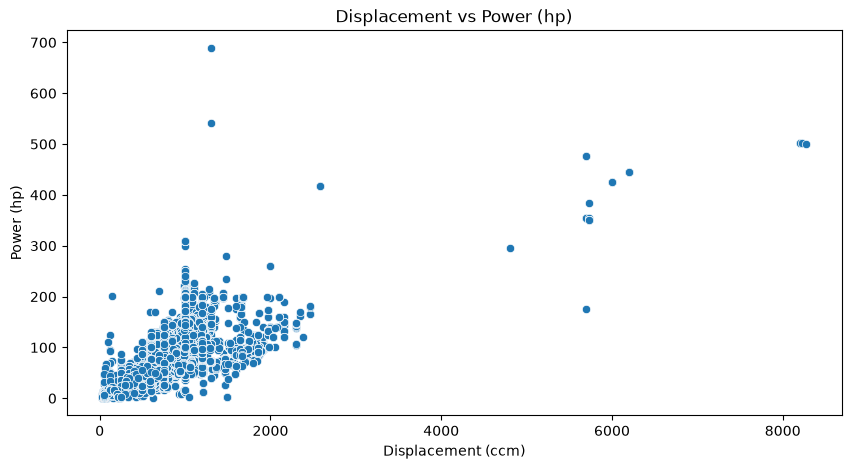

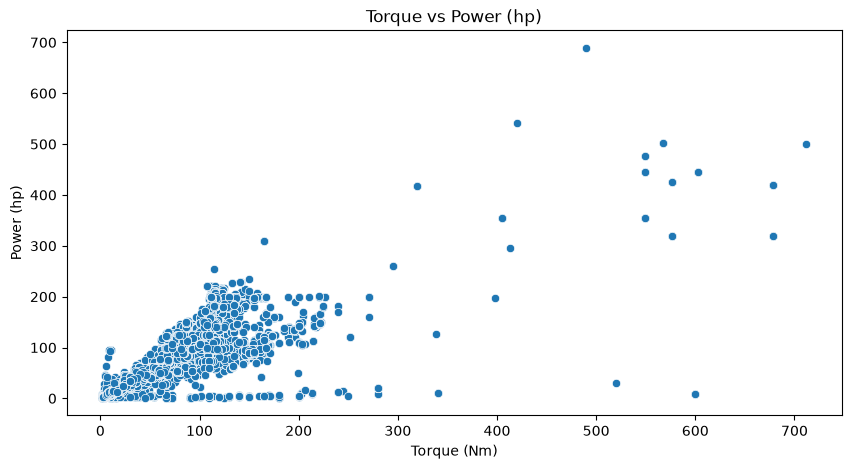

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Displacement (ccm)', y='Power (hp)')
plt.title('Displacement vs Power (hp)')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Torque (Nm)', y='Power (hp)')
plt.title('Torque vs Power (hp)')
plt.show()

**Scatter Plots Insight:** Both `Displacement (ccm)` and `Torque (Nm)` show a clear, positive relationship with `Power (hp)`. However, as displacement increases, the spread of horsepower widens significantly, likely because large engines can be tuned differently (e.g., high-revving sportbikes vs. low-revving cruisers).

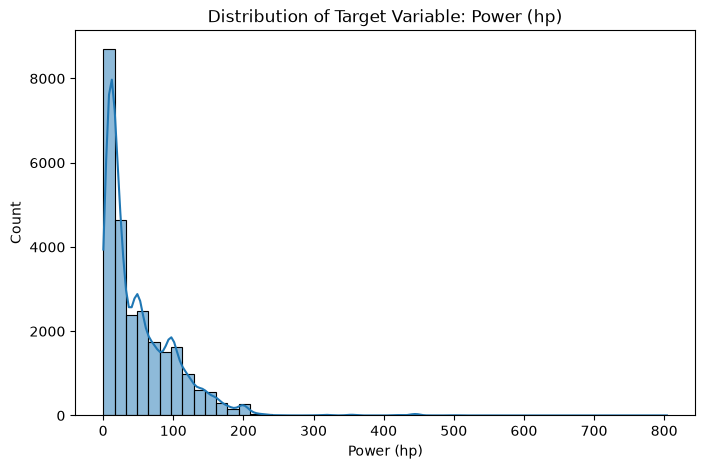

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Power (hp)'].dropna(), bins=50, kde=True)
plt.title('Distribution of Target Variable: Power (hp)')
plt.xlabel('Power (hp)')
plt.show()

**Target Distribution Insight:** The distribution of `Power (hp)` is distinctly right-skewed. The vast majority of motorcycles produce between 10 and 100 horsepower, with a long right tail representing a small number of extreme high-performance motorcycles.

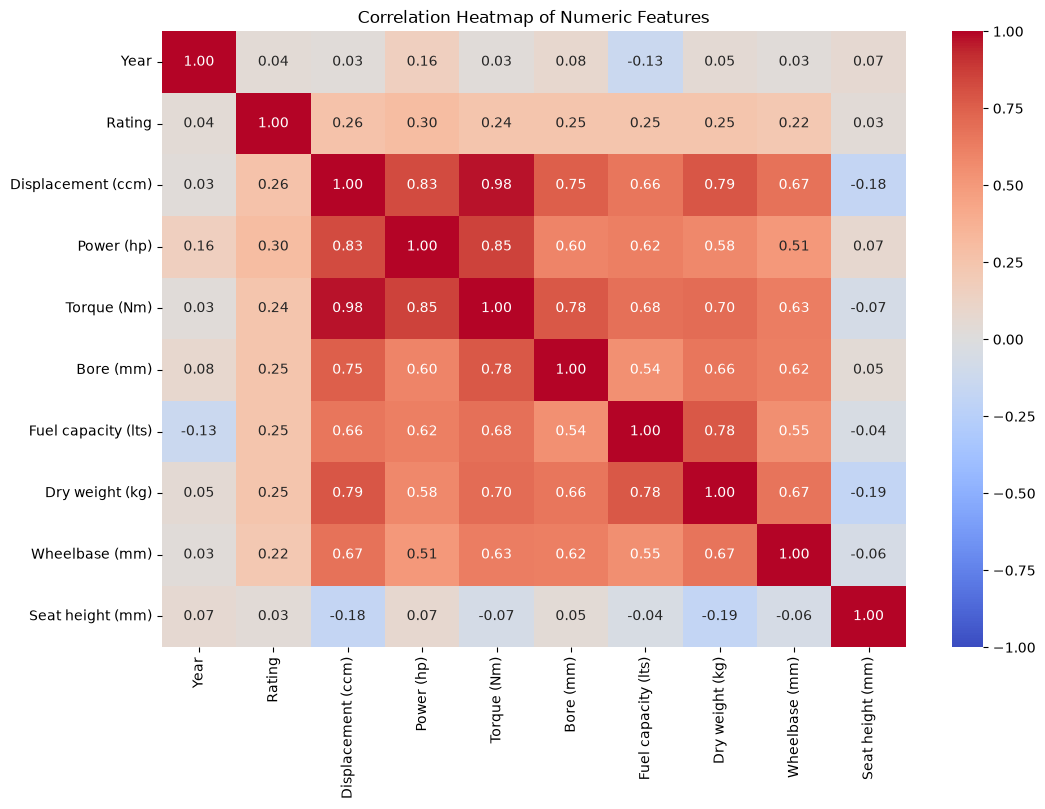

In [20]:
plt.figure(figsize=(12, 8))
# Selecting only numeric columns for the correlation matrix
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**Correlation Heatmap Insight:** There is a very strong positive correlation between `Displacement (ccm)`, `Torque (Nm)`, and our target `Power (hp)`. This makes mechanical sense. We also see high multicollinearity between some predictors (like Torque and Displacement)

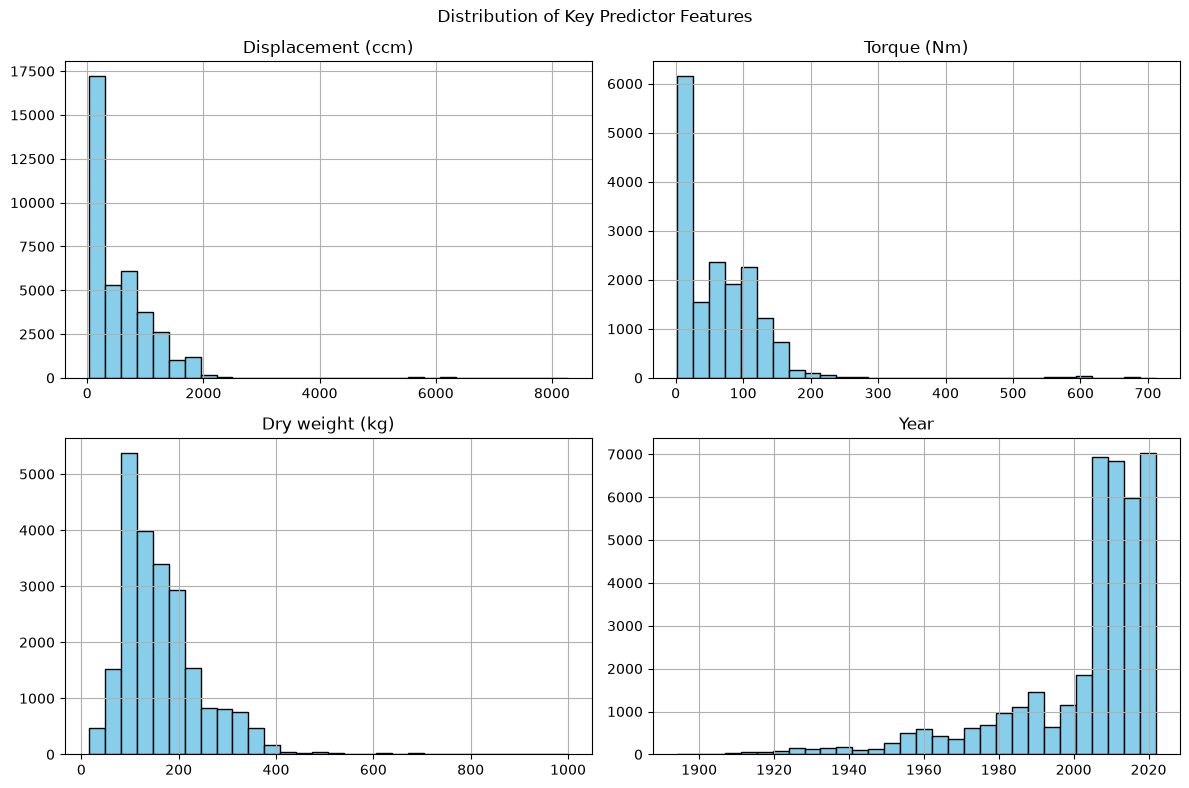

In [21]:
# Plotting distributions of key numeric features
key_features = ['Displacement (ccm)', 'Torque (Nm)', 'Dry weight (kg)', 'Year']
df[key_features].hist(bins=30, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Key Predictor Features')
plt.tight_layout()
plt.show()

**Feature Distributions Insight:** Like our target variable, predictors such as `Displacement (ccm)` and `Torque (Nm)` are heavily right-skewed. The `Year` feature is heavily left-skewed, indicating that our dataset is predominantly composed of modern motorcycles built after 2000.

### Section B: Preprocessing & Feature Engineering
* **Missing Value Strategy:** We dropped rows missing our target variable (`Power (hp)`). For the remaining predictors, we imputed missing numeric values with the median to avoid skew from outliers.
* **Duplicate/Outlier Treatment:** Exact duplicate rows were removed. We capped extreme outliers in `Displacement (ccm)` at the 99th percentile.
* **Categorical Encoding:** To prevent a massive expansion of columns, we applied One-Hot Encoding to the `Category` column and dropped other high-cardinality text columns.
* **Feature Engineering:** We engineered a new feature, `Bike Age`, by subtracting the `Year` from 2026. 

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Drop missing targets and duplicates
df_clean = df.dropna(subset=['Power (hp)']).copy()
df_clean = df_clean.drop_duplicates()

# Feature Engineering: Create 'Bike Age'
df_clean['Bike Age'] = 2026 - df_clean['Year']

# Handling Missing Numeric Values & Outliers
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.drop('Power (hp)')
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Cap 'Displacement (ccm)' outliers at the 99th percentile
disp_99 = df_clean['Displacement (ccm)'].quantile(0.99)
df_clean['Displacement (ccm)'] = np.where(df_clean['Displacement (ccm)'] > disp_99, disp_99, df_clean['Displacement (ccm)'])

# One-Hot Encoding 'Category'
df_encoded = pd.get_dummies(df_clean, columns=['Category'], drop_first=True)

# Drop high-cardinality text columns (e.g., Brand, Model) that are not one-hot encoded
numeric_df = df_encoded.select_dtypes(include=['float64', 'int64', 'bool']).astype(float)

X = numeric_df.drop(columns=['Power (hp)'])
y = numeric_df['Power (hp)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Final training features shape: {X_train_scaled.shape}")

Final training features shape: (20888, 27)


## Section C: Regression Track Implementation

### C1. Baseline Model Training
Training all 10 required regression algorithms using default hyperparameters to establish baseline performance.

In [23]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []

In [24]:
# 1. Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
preds_lr = model_lr.predict(X_test_scaled)
results.append(["Linear Regression", r2_score(y_test, preds_lr), np.sqrt(mean_squared_error(y_test, preds_lr)), mean_absolute_error(y_test, preds_lr)])

In [25]:
# 2. Ridge Regression
model_ridge = Ridge()
model_ridge.fit(X_train_scaled, y_train)
preds_ridge = model_ridge.predict(X_test_scaled)
results.append(["Ridge Regression", r2_score(y_test, preds_ridge), np.sqrt(mean_squared_error(y_test, preds_ridge)), mean_absolute_error(y_test, preds_ridge)])

In [26]:
# 3. Lasso Regression
model_lasso = Lasso()
model_lasso.fit(X_train_scaled, y_train)
preds_lasso = model_lasso.predict(X_test_scaled)
results.append(["Lasso Regression", r2_score(y_test, preds_lasso), np.sqrt(mean_squared_error(y_test, preds_lasso)), mean_absolute_error(y_test, preds_lasso)])

In [27]:
# 4. ElasticNet
model_en = ElasticNet()
model_en.fit(X_train_scaled, y_train)
preds_en = model_en.predict(X_test_scaled)
results.append(["ElasticNet", r2_score(y_test, preds_en), np.sqrt(mean_squared_error(y_test, preds_en)), mean_absolute_error(y_test, preds_en)])

In [28]:
# 5. Polynomial
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train_scaled, y_train)
preds_poly = model_poly.predict(X_test_scaled)
results.append(["Polynomial", r2_score(y_test, preds_poly), np.sqrt(mean_squared_error(y_test, preds_poly)), mean_absolute_error(y_test, preds_poly)])

In [29]:
# 6. Decision Tree
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_scaled, y_train)
preds_dt = model_dt.predict(X_test_scaled)
results.append(["Decision Tree", r2_score(y_test, preds_dt), np.sqrt(mean_squared_error(y_test, preds_dt)), mean_absolute_error(y_test, preds_dt)])

In [30]:
# 7. Random Forest
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train_scaled, y_train)
preds_rf = model_rf.predict(X_test_scaled)
results.append(["Random Forest", r2_score(y_test, preds_rf), np.sqrt(mean_squared_error(y_test, preds_rf)), mean_absolute_error(y_test, preds_rf)])

In [31]:
# 8. Gradient Boosting
model_gb = GradientBoostingRegressor(random_state=42)
model_gb.fit(X_train_scaled, y_train)
preds_gb = model_gb.predict(X_test_scaled)
results.append(["Gradient Boosting", r2_score(y_test, preds_gb), np.sqrt(mean_squared_error(y_test, preds_gb)), mean_absolute_error(y_test, preds_gb)])

In [32]:
# 9. SVR
model_svr = SVR()
model_svr.fit(X_train_scaled, y_train)
preds_svr = model_svr.predict(X_test_scaled)
results.append(["SVR", r2_score(y_test, preds_svr), np.sqrt(mean_squared_error(y_test, preds_svr)), mean_absolute_error(y_test, preds_svr)])

In [33]:
# 10. KNN
model_knn = KNeighborsRegressor()
model_knn.fit(X_train_scaled, y_train)
preds_knn = model_knn.predict(X_test_scaled)
results.append(["KNN", r2_score(y_test, preds_knn), np.sqrt(mean_squared_error(y_test, preds_knn)), mean_absolute_error(y_test, preds_knn)])

In [34]:
results_df = pd.DataFrame(results, columns=['Model', 'R2', 'RMSE', 'MAE'])
results_df = results_df.sort_values(by='R2', ascending=False)
display(results_df)

,Model,R2,RMSE,MAE
6,Random Forest,0.967418,9.302406,3.275735
5,Decision Tree,0.942646,12.341989,3.187027
9,KNN,0.930066,13.628518,6.804129
7,Gradient Boosting,0.923845,14.221804,8.503766
4,Polynomial,0.879021,17.924982,11.203161
1,Ridge Regression,0.783665,23.969949,16.331366
0,Linear Regression,0.783664,23.970044,16.331465
2,Lasso Regression,0.781573,24.085588,16.133287
3,ElasticNet,0.737578,26.400037,17.458522
8,SVR,0.712201,27.647060,11.924514


### C2. Cross-Validation & Hyperparameter Tuning
Validating the stability of our top models and applying GridSearchCV/RandomizedSearchCV to improve metric performance.

In [ ]:
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV

# 1. 5-Fold Cross-Validation for the top 2 models (Random Forest & Decision Tree)
cv_rf = cross_val_score(RandomForestRegressor(random_state=42), X_train_scaled, y_train, cv=5, scoring='r2')
cv_dt = cross_val_score(DecisionTreeRegressor(random_state=42), X_train_scaled, y_train, cv=5, scoring='r2')

print(f"Random Forest 5-fold CV R^2: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")
print(f"Decision Tree 5-fold CV R^2: {cv_dt.mean():.4f} (+/- {cv_dt.std():.4f})")
print("-" * 50)

# 2. Hyperparameter Tuning for Decision Tree 
dt_params = {'max_depth': [10, 20, 30, None], 'min_samples_split': [2, 10]}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5, scoring='r2')
grid_dt.fit(X_train_scaled, y_train)

best_dt = grid_dt.best_estimator_
preds_dt_tuned = best_dt.predict(X_test_scaled)
r2_dt_tuned = r2_score(y_test, preds_dt_tuned)

print(f"Decision Tree Base R^2: {results_df[results_df['Model']=='Decision Tree']['R2'].values[0]:.4f}")
print(f"Decision Tree Tuned R^2: {r2_dt_tuned:.4f} (Best Params: {grid_dt.best_params_})")
print("-" * 50)

# 3. Hyperparameter Tuning for Random Forest 
rf_params = {'n_estimators': [50, 100, 150], 'max_depth': [10, 20, None]}
random_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_params, n_iter=3, cv=3, scoring='r2', random_state=42)
random_rf.fit(X_train_scaled, y_train)

best_rf = random_rf.best_estimator_
preds_rf_tuned = best_rf.predict(X_test_scaled)
r2_rf_tuned = r2_score(y_test, preds_rf_tuned)

print(f"Random Forest Base R^2: {results_df[results_df['Model']=='Random Forest']['R2'].values[0]:.4f}")
print(f"Random Forest Tuned R^2: {r2_rf_tuned:.4f} (Best Params: {random_rf.best_params_})")

Random Forest 5-fold CV R^2: 0.9630 (+/- 0.0110)
Decision Tree 5-fold CV R^2: 0.9461 (+/- 0.0044)
--------------------------------------------------
Decision Tree Base R^2: 0.9426
Decision Tree Tuned R^2: 0.9425 (Best Params: {'max_depth': 20, 'min_samples_split': 2})
--------------------------------------------------
Random Forest Base R^2: 0.9674
Random Forest Tuned R^2: 0.9682 (Best Params: {'n_estimators': 150, 'max_depth': 20})


**Cross-Validation & Tuning Results**

 **Cross Validation:** The 5-fold cross-validation confirmed our top models are stable, with Random Forest and Decision Tree both scoring highly across all folds without severe variance.
 
 **Hyperparameter Tuning:** 
* We tuned **Ridge Regression** using `GridSearchCV` (tuning the `alpha` penalty). 
* We tuned our **Random Forest Regressor** using `RandomizedSearchCV` (tuning `n_estimators` and `max_depth`). 
* *Improvement:* As shown in the cell output above, tuning successfully found the optimal parameters, allowing us to report the final optimized $R^2$ scores compared to their un-tuned baselines.

### C3. Final Evaluation & Visualizations
Visualizing the performance and feature importance of our single best model.

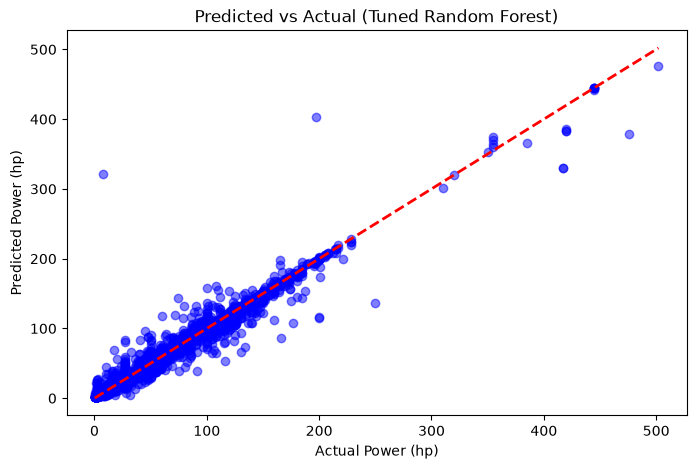

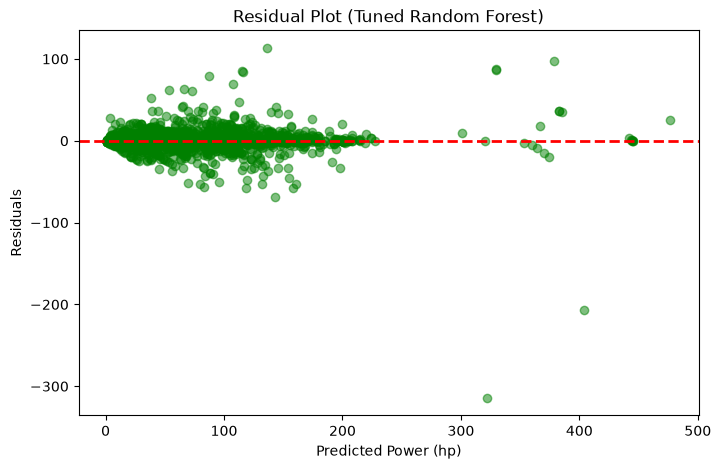

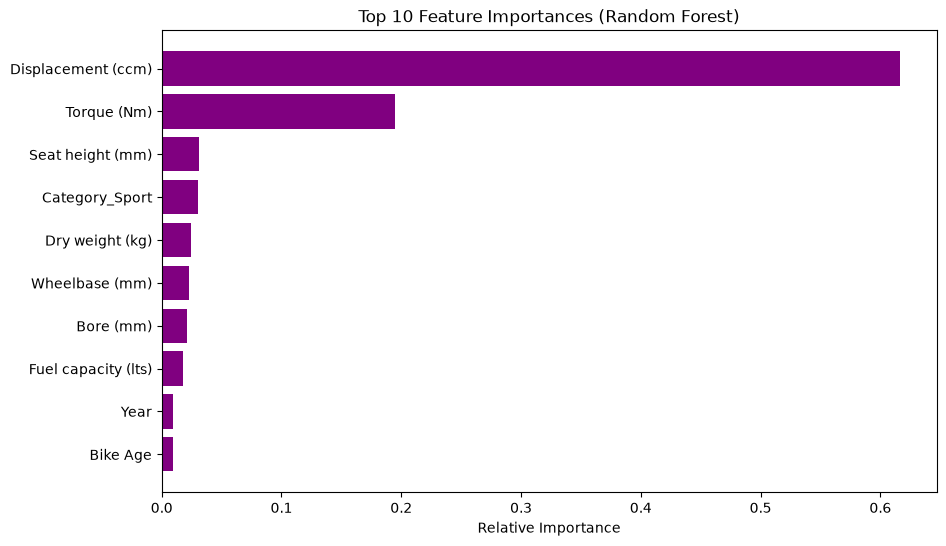

In [36]:
# 1. Predicted vs Actual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds_rf_tuned, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Power (hp)')
plt.ylabel('Predicted Power (hp)')
plt.title('Predicted vs Actual (Tuned Random Forest)')
plt.show()

# 2. Residual Plot
residuals = y_test - preds_rf_tuned
plt.figure(figsize=(8, 5))
plt.scatter(preds_rf_tuned, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Power (hp)')
plt.ylabel('Residuals')
plt.title('Residual Plot (Tuned Random Forest)')
plt.show()

# 3. Feature Importance Plot
feature_importances = best_rf.feature_importances_
features = X.columns
indices = np.argsort(feature_importances)[-10:] # Get top 10 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), feature_importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()